In [1]:
import numpy as np
from pymoo.core.mixed import MixedVariableGA
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.core.problem import ElementwiseProblem
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.core.sampling import Sampling
from pymoo.core.repair import Repair
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
%matplotlib ipympl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import geopy.distance as geo
from utils import read_data
import fluids
from scipy.interpolate import griddata, LinearNDInterpolator, RBFInterpolator
from pymoo.core.variable import Real, Integer, Choice, Binary

In [2]:
import pymoo
print(pymoo.__version__)

0.6.1.3


In [3]:
data_file = r'data\Map_village_20241227_data.csv'

data,households,pumps,open_wells = read_data(data_file)

Lon         -11.444274
Lat          10.990651
Altitude    350.000000
Name: 192, dtype: float64
[[-11.44  11.  ]] [357.24367024]


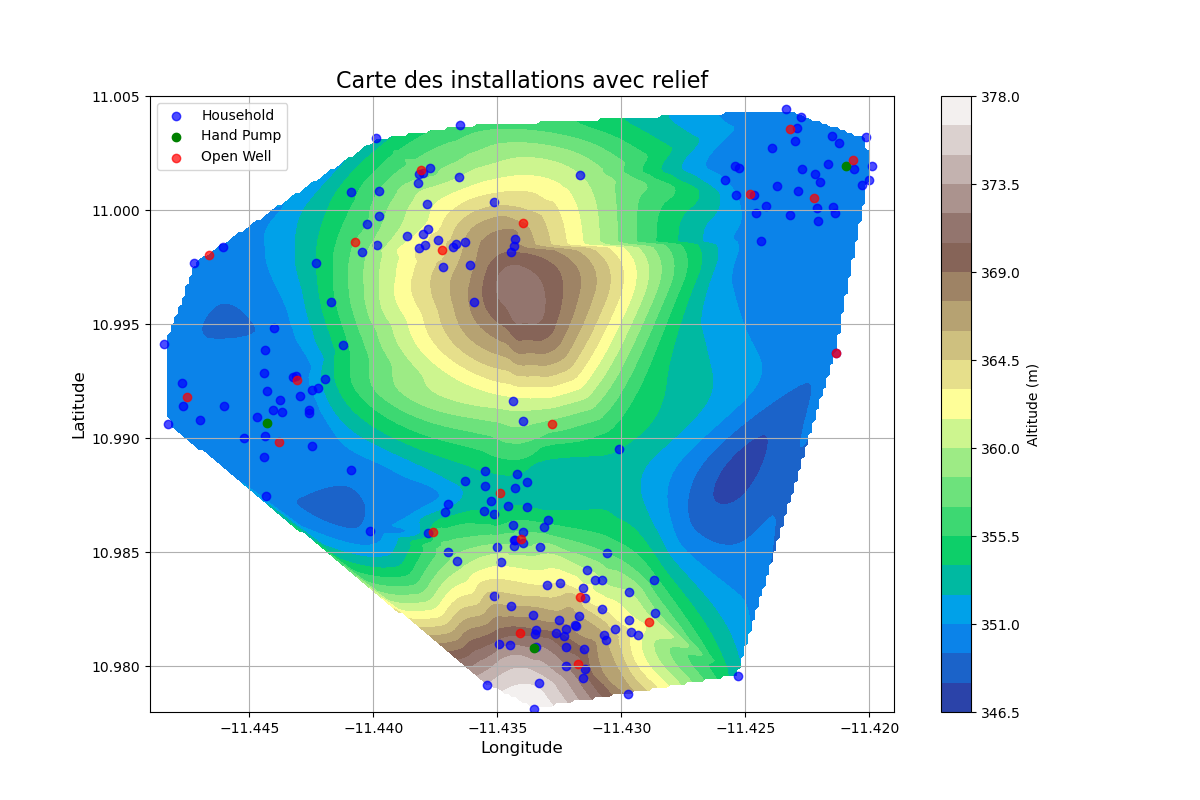

In [4]:
pos_households = households[['Lon','Lat']].to_numpy() # For f1 (sum of weighted distances)
nb_capita = households['Nb capita'].to_numpy() # Define weight factors for each distance in pos_households

pos_pumps = pumps[['Lon','Lat']].to_numpy() # For f2 (min distance)
initial_nb_pumps = len(pos_pumps)
cost_conversion=5000
cost_standpipe=1000
cost_borehole=15000
consumption_person=14 #L/person/day

baseline_consumption = np.zeros(len(pos_pumps))
min_distance_index = np.zeros(len(pos_households), dtype=int)

for index1, household in enumerate(pos_households):
    distances = np.zeros(len(pos_pumps))
    for index2, pump in enumerate(pos_pumps):
        distances[index2] = geo.great_circle((household[1], household[0]), (pump[1], pump[0])).meters
    min_distance_index[index1] = np.argmin(distances)
    baseline_consumption[min_distance_index[index1]] += nb_capita[index1] * consumption_person
    
# Créer une grille pour le relief
grid_x, grid_y = np.mgrid[data['Lon'].min():data['Lon'].max():200j, 
                          data['Lat'].min():data['Lat'].max():200j]
grid_z = griddata((data['Lon'], data['Lat']), data['Altitude'], (grid_x, grid_y), method='cubic')

interp = RBFInterpolator(np.column_stack([data['Lon'], data['Lat']]), data['Altitude'], kernel='linear')
query_points = np.column_stack((np.atleast_1d(-11.440), np.atleast_1d(11.000)))
print(pumps[['Lon','Lat','Altitude']].iloc[1])
result = interp(query_points)
print(query_points,result)

# Créer la figure
plt.figure(figsize=(12, 8))

# Tracer le relief en 2D
contour = plt.contourf(grid_x, grid_y, grid_z, levels=20, cmap='terrain')
plt.colorbar(label="Altitude (m)")

# Tracer chaque type par-dessus
plt.scatter(households['Lon'], households['Lat'], c='blue', alpha=0.7, label='Household')
plt.scatter(pumps['Lon'], pumps['Lat'], c='green', alpha=1, label='Hand Pump')
plt.scatter(open_wells['Lon'], open_wells['Lat'], c='red', alpha=0.7, label='Open Well')

# Ajouter des limites et graduations cohérentes
rounded_lat_min = np.floor(data['Lat'].min() * 1000) / 1000  # Arrondi à 3 décimales
rounded_lat_max = np.ceil(data['Lat'].max() * 1000) / 1000
rounded_lon_min = np.floor(data['Lon'].min() * 1000) / 1000
rounded_lon_max = np.ceil(data['Lon'].max() * 1000) / 1000
plt.ylim(rounded_lat_min, rounded_lat_max)
plt.xlim(rounded_lon_min, rounded_lon_max)

# Ajouter des détails
plt.title('Carte des installations avec relief', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True)
plt.legend()

# Afficher le graphique
plt.show()

In [5]:
def build_altitude_interpolator(df, kernel='linear'):
    """
    Build an interpolator that can predict altitude at any lat/lon
    using Radial Basis Function interpolation (works outside convex hull).
    
    Parameters:
        df (pd.DataFrame): must have 'lat', 'lon', 'alt' columns
        kernel (str): RBF kernel ('linear', 'cubic', 'thin_plate_spline', etc.)
        
    Returns:
        function: takes (lon, lat) and returns predicted altitude
    """
    # Prepare training points and values
    points = np.column_stack((df['Lat'], df['Lon']))
    values = df['Altitude'].values
    
    # Build RBF interpolator
    rbf = RBFInterpolator(points, values, kernel=kernel)
    
    def get_alt(point):
        (lon,lat) = point
        # Accepts scalars or arrays
        query_points = np.column_stack((np.atleast_1d(lat), np.atleast_1d(lon)))
        result = rbf(query_points)
        # Return scalar if scalar input
        return result if np.ndim(lat) > 0 else result[0]
    
    return get_alt

In [6]:
get_alt = build_altitude_interpolator(data)

In [7]:
get_alt([-11.440,11])

np.float64(357.24367024185017)

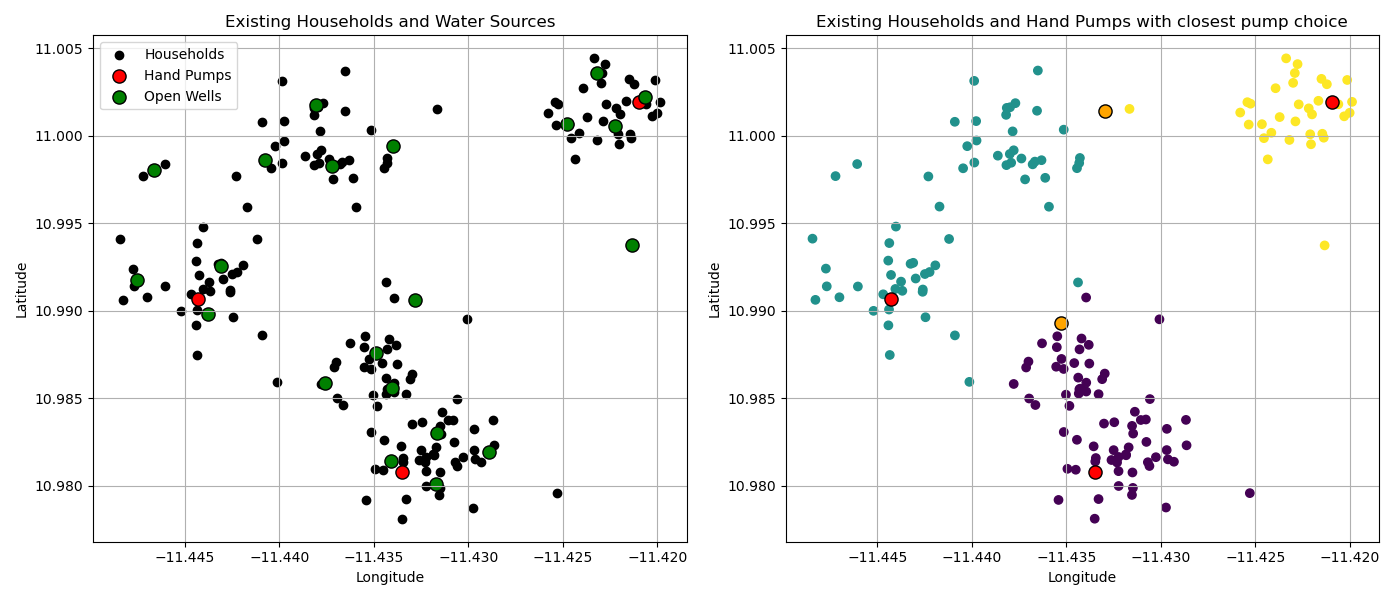

In [8]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14, 6))
# Plot households (black dots)
ax1.scatter(households['Lon'], households['Lat'], color='black', label='Households')
# Plot previous pumps (red)
ax1.scatter(pos_pumps[:, 0], pos_pumps[:, 1], color='red', label='Hand Pumps', edgecolors='k', s=90)
# Plot open wells (green)
ax1.scatter(open_wells['Lon'], open_wells['Lat'], color='green', label='Open Wells', edgecolors='k', s=90)

ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title(f'Existing Households and Water Sources')
ax1.legend()
ax1.grid(True)

# Ax2 Colour households by pump choice
# Plot households (black dots)
ax2.scatter(households['Lon'], households['Lat'], c=min_distance_index, label='Households')
# Plot previous pumps (red)
ax2.scatter(pos_pumps[:,0],pos_pumps[:,1], color='red', label='Hand Pumps', edgecolors='k', s=90)
#ax2.scatter(pos_pumps[1, 0], pos_pumps[1, 1], color='pink', label='Pump selected', edgecolors='k', s=90)

pos_newpumps = np.array([[  1.,           2.,         -11.43530671,  10.98921184, -11.43591305,
                        11.00140855],
                        [  1.,           2.    ,     -11.44573017,  10.99024575, -11.42767991,
                        11.00134302],
                        [  1.,           2.,         -11.43530671,  10.98929659, -11.43297497,
                        11.00140785],
                        [  1.,           2.,         -11.43530883,  10.99913305, -11.42138812,
                        11.00140785],
                        [  1. ,          2.     ,    -11.4457327 ,  10.98891283, -11.43208656,
                        11.00194177],
                        [  1.    ,       2.     ,    -11.43537707 , 10.99849363, -11.42283705,
                        11.00317231],
                        [  1.  ,         2.   ,      -11.43584319,  10.98929659, -11.4358731,
                        11.00124575],
                        [  1.    ,       2.   ,      -11.43738764 , 10.98746347, -11.42297931,
                        11.0031694 ],
                        [  1.      ,     2.   ,      -11.44573017,  10.9903305 , -11.43117669,
                        11.00165301],
                        [  1.  ,         2.   ,      -11.44573017 , 10.99024575, -11.42884575,
                        11.00134302]])
ax2.scatter([pos_newpumps[2, 2],pos_newpumps[2, 4]], [pos_newpumps[2, 3],pos_newpumps[2, 5]],color='orange',label='New Pumps', edgecolors='k', s=90)


ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_title(f'Existing Households and Hand Pumps with closest pump choice')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [9]:
def pump_distance(
    pump_positions: np.ndarray,
    household_positions: np.ndarray,
    x: np.ndarray|None = None,
    ):
    """_summary_

    Args:
        pump_positions (np.ndarray): 
            Array of [lon, lat] positions of pumps
        household_positions (np.ndarray): 
            Array of [lon, lat] positions of households
        x (np.ndarray, optional): 
            Position of potential new pump [lon,lat] (only 1). Defaults to None.
        
    Returns:
        min_pump_distance (np.ndarray): 
            Array of distances (len(household_positions))
            to closest pump for each household
        min_pump_distance_index (np.ndarray): 
            Array (len(household_positions)) of 
            index of closest pump for each household
    """
    
    # Make copy and add x to pump array if it exists
    pump_positions_copy = pump_positions.copy()
    if isinstance(x, np.ndarray):
        pump_positions_copy = np.vstack((pump_positions_copy,np.array(x)))
        
    # Create arrays to assign values to
    min_pump_distance = np.zeros(len(household_positions))
    min_pump_distance_index = np.zeros(len(household_positions))
    
    for index,pos_household in enumerate(household_positions):
        dist = np.zeros(len(pump_positions_copy))
        for i,pump_pos in enumerate(pump_positions_copy):
            dist[i] = geo.great_circle(pump_pos, pos_household).meters
        min_pump_distance[index] = np.min(dist)
        min_pump_distance_index[index] = np.argmin(dist)
    
    return min_pump_distance, min_pump_distance_index
    

In [10]:
# # get min pump distances and indices
# min_distances, min_indices = pump_distance(pump_positions,household_positions,x)

In [11]:
### This is a DAILY value, and so if we want to calculate more realistic pressure losses/pump requirements, need to have a peak value i.e. daily-->peak Q function (graph of daily usage etc)

def get_consumption(min_indices, household_consumption):
    """
    Takes indices of the closest pump from households as well as per household consumption
    Returns consumption at each pump
    """
    
    consumption_pump = np.zeros(len(household_consumption))
    for i,pump in min_indices:
        consumption_pump[pump] += household_consumption[i]
    
    return consumption_pump

    

## Pipe flow

In [12]:
pump_data = {
    'name': 'Pentax Ultra 7S-120/3 Horizontal Multistage Booster Pump 240v',
    'head_increase': 30, # m
    'cost': 400, # €
}
pipe_costs = { # keys are pipe diameters, values are pipe costs €/m (source AO_GRP.1_GALLON_DUVAL_ROBILLOT_JIMENEZ)
    0.02: 0.65,
    0.025: 1.5,
    0.032: 2.69,
    0.04: 3.5,
    0.05: 5,
    0.06: 5,
}


In [13]:
def pipe_and_pump_cost(
    alt1: float,
    alt2: float,
    length_pipe: float,
    flow_rate: float,
    pump_data: dict,
    pipe_costs: dict,
    )-> tuple[float, float, float]:
    """_summary_

    Args:
        alt1 (float): 
            Altitude of point 1 (water start)
        alt2 (float): 
            Altitude of point 2 (water end)
        length_pipe (float): 
            Length of pipe (m)
        flow_rate (float): 
            Max flow rate required (m^3/s)
        pump_data (dict): 
            Details of pump(s) used with cost and head increase
        pipe_costs (dict): 
            Keys of pipe diameters, values of their cost/m (€/m)

    Returns:
        tuple[float, float, float]: 
            Minimum cost at this point, diameter of pipe chosen and nb pumps required
    """
    
    rho = 1000
    g=9.81
    mu = 1e-3
    epsilon = 0.005e-3
    K = 20 # To decide depending on how pipe flows

    p_pump = pump_data['head_increase']*rho*g
    pump_cost = pump_data['cost']
    min_pipe_cost = np.inf

    for d,cost_pipe in pipe_costs.items():
        V = flow_rate/(np.pi*d**2/4)
        ReD = rho*V*d/mu
        
        # Darcy friction factor using Clamond method
        f = fluids.friction_factor(Re = ReD,eD = epsilon/d)
        
        # Loss coefficients
        K_f = f*length_pipe/d
        K_output_flow = 1 # (releasing water to open atmosphere)
        K_total = K + K_f + K_output_flow
        
        # Pressure loss using gravity and losses
        p_loss = rho*g*(alt2-alt1) + 0.5*rho*V**2*K_total
        
        # Number of pumps required (for the specified pump in pump_data)
        # as well as cost required 
        nb_pumps = np.ceil(p_loss/p_pump)
        if nb_pumps>0:
            cost_pump = nb_pumps*pump_cost
        else:
            cost_pump = 0
        
        # Total cost using pumps and length of pipe
        total_cost = cost_pump + cost_pipe*length_pipe

        # Set the total cost, diameter and number of pumps required
        if total_cost < min_pipe_cost:
            min_pipe_cost = total_cost
            diameter_pipe = d
            nb_pumps_final = nb_pumps
        
    # Return minimum cost for given location
    if type(min_pipe_cost) != float:
        min_pipe_cost.astype(float)
        
    return min_pipe_cost, diameter_pipe, nb_pumps_final

In [14]:
cost,di,nfp = pipe_and_pump_cost(10,0,850,1e-3,pump_data,pipe_costs)
print(cost)

3086.5


In [15]:
# Hazen-Williams
rho = 1000
g = 9.81
h2 = 0
h1 = 0
Q = 1e-3
L=100
C=140
efficiency_pump = 0.9

D = np.asarray([0.02,0.025,0.032,0.04,0.05,0.063])

h_drop = 10.67*Q**(1.852)*L/(C**1.852)/D**4.8704
p_loss = h_drop*rho*g

p_drop_total = rho*g*(h2-h1)+p_loss

power_pump = p_drop_total*Q/efficiency_pump





## Tree Branching

In [16]:
import networkx as nx
import random

def initialize_topology(fixed_nodes, new_nodes, seed=None):
    """
    Initialize a random valid topology where each new node has a parent
    that is either a fixed node or a previously connected new node.
    
    Args:
        fixed_nodes (list): names of fixed nodes (e.g., ['F1', 'F2'])
        new_nodes (list): names of new nodes (e.g., ['N1', 'N2', 'N3'])
        seed (int): random seed for reproducibility

    Returns:
        nx.DiGraph: directed graph of child → parent relationships
    """
    if seed is not None:
        random.seed(seed)

    G = nx.DiGraph()
    G.add_nodes_from(fixed_nodes + new_nodes)

    connected_nodes = set(fixed_nodes)  # start with fixed nodes

    for node in new_nodes:
        # pick a parent from nodes already connected to the network
        parent = random.choice(list(connected_nodes))
        G.add_edge(node, parent)
        
        # once connected, this node can be a parent for later nodes
        connected_nodes.add(node)

    return G


In [17]:
# Example usage
fixed_nodes = pumps.index.to_list()
new_nodes = ["N1", "N2"]

topology = initialize_topology(fixed_nodes, new_nodes, seed=12)

print("Edges (child → parent):")
for edge in topology.edges:
    print(edge)

# Check connectivity
for new_node in new_nodes:
    # Check if there is a path from the new_node to any fixed node
    has_path = any(nx.has_path(topology, new_node, fixed_node) for fixed_node in fixed_nodes)
    assert has_path, f"No path found from {new_node} to any fixed node!"

Edges (child → parent):
('N1', 193)
('N2', 'N1')


In [35]:
def impact(original_pump_positions, household_positions, household_capita, x = None):
    min_pump_distance, min_pump_dist_indices = pump_distance(original_pump_positions, household_positions, x)

    impact = np.sum(household_capita * (min_pump_distance))/1000 # thousand-person-metres
    return impact

initial_impact = impact(pos_pumps,pos_households,nb_capita)

In [19]:
def impact2(original_pump_positions, household_positions, household_capita, x = None):
    min_pump_distance, min_pump_dist_indices = pump_distance(original_pump_positions, household_positions, x)

    walking_speed = 15/1000 # 15min/km (in min/m)
    min_pump_time = min_pump_distance * walking_speed
    nb_within_margin = 0
    for i,t in enumerate(min_pump_time):
        if t*2 < 30:
            nb_within_margin += nb_capita[i]
    
    percent_within_time = nb_within_margin/sum(household_capita)*100*-1 #negative percentage
    
    return percent_within_time

initial_impact = impact2(pos_pumps,pos_households,nb_capita)

In [20]:
bounds = np.array([
        [data['Lon'].min(), data['Lat'].min()],  # Min bounds
        [data['Lon'].max(), data['Lat'].max()],  # Max bounds
    ])

In [21]:
class TopologyPositionProblem(ElementwiseProblem):
    def __init__(self, fixed_nodes, fixed_coords, fixed_heights,
                 house_coords, house_weights,
                 n_new_nodes,
                 bounds_xy,
                 impact_fn,
                 **kwargs):
        m = len(fixed_nodes)
        n = n_new_nodes
        
        x_bounds = bounds_xy[:,0]
        y_bounds = bounds_xy[:,1]
        #vars = parent_vars+new_node_vars
        vars = {}

        # Parents: n integers, each in [0, m + n - 1]
        for i in range(n):
            vars[f"parent_{i}"] = Integer(bounds=(0, m + n - 1))
        
        # Coordinates: n real-valued pairs (x, y)
        for i in range(n):
            vars[f"x_{i}"] = Real(bounds=x_bounds)
            vars[f"y_{i}"] = Real(bounds=y_bounds)
            
        # for i in range(n):
        #     vars[f"borehole_{i}"] = Binary()        
        
        super().__init__(vars= vars,#,  # parents + coords
                         n_obj=2,
                         n_constr=0,
                        #  xl=xl,
                        #  xu=xu,
                         **kwargs)
        self.fixed_nodes = fixed_nodes
        self.fixed_coords = fixed_coords
        self.fixed_heights = fixed_heights
        self.house_coords = house_coords
        self.house_weights = house_weights
        self.n_new_nodes = n_new_nodes
        self.bounds_xy = bounds_xy
        self.initial_impact = impact_fn(pos_pumps,pos_households,nb_capita)
        self.impact_fn = impact_fn
    
    def _evaluate(self, X, out, *args, **kwargs):
        """
        x format:
        [parent_0, parent_1, ..., parent_{n-1}, x_0, y_0, ..., x_{n-1}, y_{n-1}]
        """
        #print(X['parent_0'])
        m = len(self.fixed_nodes)
        n = self.n_new_nodes
        parents = X[:n].astype(int)
        coords = X[n:3*n].reshape(n,2)
        #borehole_binaries = X[3*n:4*n]
        borehole_binaries = np.zeros(n)
        for i,p in enumerate(parents):
            if p - m == i:
                borehole_binaries[i] = 1
        
        # Build graph and check validity
        G = nx.DiGraph()
        all_nodes = list(self.fixed_nodes) + [f"N{i}" for i in range(n)]
        G.add_nodes_from(all_nodes)
        
        converted_fixed_pumps = np.zeros(m)
        pipe_data = np.zeros(shape=(n,4))
        
        # Add edges child->parent for new nodes
        for i, p in enumerate(parents):
            if borehole_binaries[i] == 0:
                #if a borehole does NOT exist here
                child = f"N{i}"
                if p < len(self.fixed_nodes):
                    parent = self.fixed_nodes[p]
                else:
                    parent = f"N{p - len(self.fixed_nodes)}"
                G.add_edge(child, parent)
            elif borehole_binaries[i] == 1:
                # if a borehole DOES exist
                pass
            else:
                print(borehole_binaries[i])
                raise ValueError("Borehole value not 0 or 1")
                
        
        # Check acyclic
        if not nx.is_directed_acyclic_graph(G):
            #print("Acyclic Graph err")
            out["F"] = [1e6, 1e6]  # large penalty
            out["pipe_data"] = [pipe_data]
            return
        
        # Check connectivity: all new nodes connected to fixed nodes
        for i in range(n):
            if borehole_binaries[i] == 0:
                child = f"N{i}"
                if not any(nx.has_path(G, child, fn) for fn in self.fixed_nodes):
                    #print("Not full connectivity err")
                    out["F"] = [1e6, 1e6]
                    out["pipe_data"] = [pipe_data]
                    return
            else:
                pass
            
        # Compute weighted sum of distances to points in pos_households with all nodes
        f1 = self.impact_fn(self.fixed_coords,self.house_coords,self.house_weights,coords)  # Negative impact calculation with new x location
        
        height_new_nodes = np.asarray([get_alt(i) for i in coords])
        
        # else:
        G_rev = G.reverse()
        f2 = 0
        for i,p in enumerate(parents):
            f2 += cost_standpipe
            if borehole_binaries[i] == 1:
                f2 += cost_borehole
                pipe_data[i] = np.ones(shape=(1,4))
                continue
            coord_new_node = coords[i]
            alt2 = height_new_nodes[i]
            child = f"N{i}"
            
            if p < m:
                # Parent is a fixed node
                parent_coord = self.fixed_coords[p]
                alt1 = self.fixed_heights[p]
                
                if converted_fixed_pumps[p] == 0:
                    f2 += cost_conversion
                    converted_fixed_pumps[p] = 1
            else:
                # Parent is a new node
                parent_index = p - m
                parent_coord = coords[parent_index]
                alt1 = height_new_nodes[parent_index]

            length_pipe = geo.great_circle(parent_coord, coord_new_node).meters
            descendants = nx.descendants(G_rev, child) # find how many nodes are connected
            num_descendants = len(descendants)                
            flow_rate = 1e-3 * (num_descendants+1) # Takes care of additional connections
            if flow_rate == 0:
                continue
            
            (cost_pipe_and_pumps, diameter_pipe, nb_pumps
                ) = pipe_and_pump_cost(alt1=alt1,alt2=alt2,
                                    length_pipe=length_pipe,
                                    flow_rate=flow_rate,pump_data=pump_data,
                                    pipe_costs=pipe_costs)
                
            pipe_data[i] = np.array([coord_new_node[0],coord_new_node[1],diameter_pipe,nb_pumps])
            
            f2 += cost_pipe_and_pumps
        
        out["F"] = [f1, f2]
        out["pipe_data"] = [pipe_data]
        

In [22]:
x = np.zeros(shape=(2,4))
print(x)
x[0] = np.ones(shape=(1,4))
print(x)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[1. 1. 1. 1.]
 [0. 0. 0. 0.]]


In [23]:
# -------------------------
# 1) Mixed variable sampler
# -------------------------
class MixedSampler(Sampling):
    def _do(self, problem, n_samples, **kwargs):
        var_items = list(problem.vars.items())  # preserve variable order
        n_var = len(var_items)
        X = np.zeros((n_samples, n_var), dtype=float)

        for i, (name, var) in enumerate(var_items):
            if isinstance(var, Integer):
                low, high = var.bounds
                X[:, i] = np.random.randint(low, high + 1, size=n_samples)
            elif isinstance(var, Real):
                low, high = var.bounds
                X[:, i] = np.random.uniform(low, high, size=n_samples)
            elif isinstance(var, Binary):
                X[:, i] = np.random.randint(0, 2, size=n_samples)  # only 0 or 1
            else:
                raise NotImplementedError(f"Sampler not implemented for var type {type(var)}")

        return X


# -------------------------
# 2) Repair operator (integer/binary fixes)
# -------------------------
class RoundRepair(Repair):
    def _do(self, problem, X, **kwargs):
        X = X.copy()
        var_items = list(problem.vars.items())

        for i, (_, var) in enumerate(var_items):
            if isinstance(var, Integer):
                low, high = var.bounds
                X[:, i] = np.clip(np.round(X[:, i]), low, high)
            elif isinstance(var, Binary):
                # force strictly 0 or 1
                X[:, i] = np.where(X[:, i] >= 0.5, 1, 0)
            elif isinstance(var, Real):
                low, high = var.bounds
                X[:, i] = np.clip(X[:, i], low, high)
            # Choice and other types would be handled separately if needed

        return X


# -------------------------
# 3) Helper: numeric bounds attachment
# -------------------------
def attach_numeric_bounds(problem):
    var_items = list(problem.vars.items())
    xl = []
    xu = []
    for name, var in var_items:
        if isinstance(var, Integer) or isinstance(var, Real):
            low, high = var.bounds
        elif isinstance(var, Binary):
            low, high = 0, 1  # explicitly set binary bounds
        else:
            raise NotImplementedError(f"Bounds extraction not implemented for var type {type(var)}")

        xl.append(low)
        xu.append(high)

    problem.xl = np.array(xl, dtype=float)
    problem.xu = np.array(xu, dtype=float)

    return problem.xl, problem.xu, var_items

In [24]:
def calculate_optimal_placement(n_new_nodes):    
    problem = TopologyPositionProblem(
        fixed_nodes=pumps.index.to_list(),
        fixed_coords=pos_pumps,
        fixed_heights=pumps['Altitude'].to_numpy(),
        house_coords=pos_households,
        house_weights=nb_capita,
        n_new_nodes=n_new_nodes,
        bounds_xy=bounds,
        impact_fn=impact
    )
    xl, xu, var_items = attach_numeric_bounds(problem)

    algorithm = NSGA2(
        pop_size=20,
        sampling=MixedSampler(),
        repair=RoundRepair()
    )

    res = minimize(problem,
                algorithm,
                ('n_gen', 100),
                seed=4,
                verbose=True)

    return res

In [25]:
all_result_vals = []
all_indices = []
all_positions = []
all_boreholes = []
pipe_data = []
for i in range(1,4):
    res = calculate_optimal_placement(i)
    all_result_vals.append(res.F)
    all_indices.append(res.X[:,:i])
    all_positions.append(res.X[:,i:3*i])
    all_boreholes.append(res.X[:,3*i:4*i])
    pipe_data.append(res.pop.get("pipe_data"))

concatenated_result_vals = np.concatenate(all_result_vals)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       20 |      5 |             - |             -
     2 |       40 |      9 |  0.1093904060 |         ideal
     3 |       60 |     10 |  0.0033009494 |         ideal
     4 |       80 |     13 |  0.2377678308 |         ideal
     5 |      100 |      6 |  0.0057608535 |         ideal
     6 |      120 |      9 |  0.0523560334 |             f
     7 |      140 |     15 |  0.1173628808 |         ideal
     8 |      160 |     18 |  0.0730122678 |         ideal
     9 |      180 |     20 |  0.0150815914 |             f
    10 |      200 |     20 |  0.0082107080 |         ideal
    11 |      220 |     20 |  0.0095032719 |             f
    12 |      240 |     20 |  0.0075973275 |             f
    13 |      260 |     20 |  0.0041841851 |         ideal
    14 |      280 |     20 |  0.0128935836 |             f
    15 |      300 |     20 |  0.0063475443 |             f
    16 |      320 |     20 |  0.0088594704 |            

In [33]:
print(all_result_vals)

[array([[  378.46347276, 10332.46701236],
       [  567.2271523 ,  6400.43471489],
       [  405.40047456,  9112.54202638],
       [  386.79178723, 10061.00628523],
       [  426.22334371,  8849.50815906],
       [  431.76527022,  8734.37721735],
       [  511.08089774,  6993.05492973],
       [  488.05156052,  7322.29343665],
       [  446.31656773,  8449.79906513],
       [  498.72789142,  7173.85138206],
       [  473.55639157,  7864.22106524],
       [  453.73414532,  8260.91726858],
       [  535.59998179,  6607.23593132],
       [  553.39745038,  6483.92095149],
       [  467.84905281,  8003.38392189],
       [  474.74028297,  7521.1274878 ],
       [  523.58750075,  6940.53288874],
       [  530.73417903,  6871.71260028],
       [  564.09295757,  6411.76317056],
       [  493.65842601,  7259.14386668]]), array([[  532.49177559,  7688.10145459],
       [  289.50232263, 14630.52083135],
       [  511.80575687,  8030.91431967],
       [  490.88662467,  8482.2963452 ],
       [  434

In [27]:
rho = 1000
g=9.81
mu = 1e-3
epsilon = 0.005e-3
K = 20 # To decide depending on how pipe flows

p_pump = pump_data['head_increase']*rho*g
pump_cost = pump_data['cost']
min_pipe_cost = np.inf
new_pump_coords = [-11.44340473, 10.99029255]
length_pipe = geo.great_circle(pos_pumps[1], new_pump_coords).meters
alt1 = pumps['Altitude'].to_numpy()[1]+10
alt2 = get_alt(new_pump_coords)
flow_rate = 1e-3

for d,cost_pipe in pipe_costs.items():
    V = flow_rate/(np.pi*d**2/4)
    ReD = rho*V*d/mu
    
    # Darcy friction factor using Clamond method
    f = fluids.friction_factor(Re = ReD,eD = epsilon/d)
    
    # Loss coefficients
    K_f = f*length_pipe/d
    K_output_flow = 1 # (releasing water to open atmosphere)
    K_total = K + K_f + K_output_flow
    
    # Pressure loss using gravity and losses
    p_loss = rho*g*(alt2-alt1) + 0.5*rho*V**2*K_total
    
    # Number of pumps required (for the specified pump in pump_data)
    # as well as cost required 
    nb_pumps = np.ceil(p_loss/p_pump)
    if nb_pumps>0:
        cost_pump = nb_pumps*pump_cost
    else:
        cost_pump = 0
    
    # Total cost using pumps and length of pipe
    total_cost = cost_pump + cost_pipe*length_pipe

    print(p_loss,d,nb_pumps)
    # Set the total cost, diameter and number of pumps required
    if total_cost < min_pipe_cost:
        min_pipe_cost = total_cost
        diameter_pipe = d
        nb_pumps_final = nb_pumps
        p_loss_final = p_loss
    
# Return minimum cost for given location
if type(min_pipe_cost) != float:
    min_pipe_cost.astype(float)

556836.1588438763 0.02 2.0
131011.48389759146 0.025 1.0
-25880.458828050192 0.032 -0.0
-72693.90885505236 0.04 -0.0
-89350.92314320435 0.05 -0.0
-94637.11054082321 0.06 -0.0


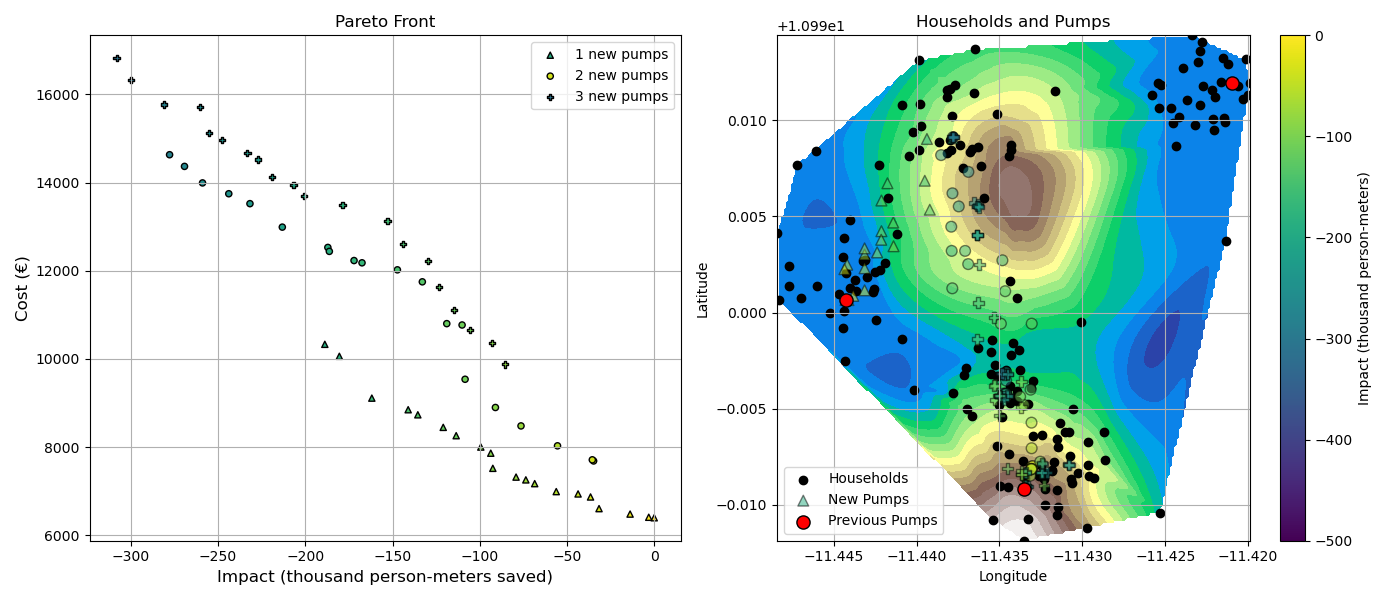

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Enable interactive widgets in Jupyter
%matplotlib widget

class InteractiveParetoPlot:
    def __init__(self, concatenated_result_vals, all_positions, all_result_vals, all_indices, 
                 households, pos_pumps, grid_x, grid_y, grid_z, initial_impact, pipe_data):
        # Store data
        self.concatenated_result_vals = concatenated_result_vals
        self.all_positions = all_positions
        self.all_result_vals = all_result_vals
        self.all_indices = all_indices
        self.households = households
        self.pos_pumps = pos_pumps
        self.grid_x = grid_x
        self.grid_y = grid_y
        self.grid_z = grid_z
        self.initial_impact = initial_impact
        self.pipe_data = pipe_data
        
        # Create figure and axes
        self.fig, (self.ax1, self.ax2) = plt.subplots(1, 2, figsize=(14, 6))
        
        # Store references to plot elements for highlighting
        self.pareto_scatter = None
        self.pump_scatters = []
        self.pump_lines = []
        self.highlighted_pumps = []
        self.highlighted_lines = []
        self.data_box = None  # Single data box that gets updated
        
        # Current hover index
        self.current_hover_idx = None
        
        self.setup_plots()
        self.connect_events()
    
    def setup_plots(self):
        """Set up both plots"""
        # === PARETO PLOT (ax1) ===
        n_tested = [1,2,3]
        n_shape = {1: '^', 2: 'o', 3: 'P'}
        
        # Store all scatter plots for hover detection
        self.pareto_scatters = []
        
        for n, k in enumerate(n_tested):
            scatter = self.ax1.scatter(
                self.all_result_vals[n][:, 0]-self.initial_impact, 
                self.all_result_vals[n][:, 1],
                c=self.all_result_vals[n][:, 0]-self.initial_impact,
                cmap='viridis',
                vmin=-500,
                vmax=0,
                edgecolor='k',
                s=20,
                label=f'{k} new pumps',
                marker=n_shape[k],
            )
            self.pareto_scatters.append(scatter)
        
        self.ax1.set_xlabel('Impact (thousand person-meters saved)', fontsize=12)
        self.ax1.set_ylabel('Cost (€)', fontsize=12)
        self.ax1.set_title('Pareto Front', fontsize=12)
        self.ax1.legend()
        self.ax1.grid(True)
        
        # === GEOGRAPHICAL PLOT (ax2) ===
        contour = self.ax2.contourf(self.grid_x, self.grid_y, self.grid_z, levels=20, cmap='terrain')
        
        # Plot households (black dots)
        self.ax2.scatter(self.households['Lon'], self.households['Lat'], color='black', label='Households')
        
        # Plot new pumps and store references
        pump_idx = 0  # Index to track pumps across all configurations
        
        for n, k in enumerate(n_tested):
            for i in range(k):
                pos_pumps_new_plot = self.all_positions[n][:,2*i:2*(i+1)]
                sc = self.ax2.scatter(
                    pos_pumps_new_plot[:, 0], pos_pumps_new_plot[:, 1],
                    c=self.all_result_vals[n][:, 0]-self.initial_impact,
                    cmap='viridis', 
                    edgecolor='k',
                    vmin=-500,
                    vmax=0,
                    s=60,
                    label='New Pumps' if pump_idx == 0 else "",
                    marker=n_shape[k],
                    alpha=0.5
                )
                self.pump_scatters.append(sc)
                
                # Store lines for each solution in this pump configuration
                lines_for_config = []
                for j in range(len(pos_pumps_new_plot)):  # For each solution
                    solution_lines = []
                    if j < len(self.all_indices[n]) and i < self.all_indices[n].shape[1]:
                        if self.all_indices[n][j,i] < len(self.pos_pumps):
                            x = int(self.all_indices[n][j,i])
                            parent_coord = self.pos_pumps[x]
                        else:
                            x = int(self.all_indices[n][j,i] - len(self.pos_pumps))
                            if x < len(pos_pumps_new_plot):
                                parent_coord = self.all_positions[n][j,2*x:2*(x+1)]
                            else:
                                continue
                        
                        points_to_plot = np.array([pos_pumps_new_plot[j], parent_coord])
                        line, = self.ax2.plot(
                            points_to_plot[:, 0], points_to_plot[:, 1],
                            c='black',
                            alpha=0,
                            linewidth=1
                        )
                        solution_lines.append(line)
                    lines_for_config.append(solution_lines)
                
                self.pump_lines.append(lines_for_config)
                pump_idx += 1
        
        # Plot previous pumps (red)
        self.ax2.scatter(self.pos_pumps[:, 0], self.pos_pumps[:, 1], 
                        color='red', label='Previous Pumps', edgecolors='k', s=90)
        
        # Add colorbar
        if len(self.pump_scatters) > 0:
            cbar = self.fig.colorbar(self.pareto_scatters[-1], ax=self.ax2)
            cbar.set_label('Impact (thousand person-meters)')
        
        # Labels and title
        self.ax2.set_xlabel('Longitude')
        self.ax2.set_ylabel('Latitude')
        self.ax2.set_title('Households and Pumps')
        self.ax2.legend()
        self.ax2.grid(True)
        
        plt.tight_layout()
    
    def connect_events(self):
        """Connect mouse events"""
        self.fig.canvas.mpl_connect('motion_notify_event', self.on_hover)
    
    def on_hover(self, event):
        """Handle hover events over the Pareto plot"""
        if event.inaxes == self.ax1:
            # Check each scatter plot for hover
            hover_idx = None
            cumulative_solutions = 0
            
            for n, scatter in enumerate(self.pareto_scatters):
                cont, ind = scatter.contains(event)
                if cont:
                    # Get the index within this scatter plot
                    local_idx = ind["ind"][0]
                    # Convert to global index
                    hover_idx = cumulative_solutions + local_idx
                    break
                cumulative_solutions += len(self.all_result_vals[n])
            
            if hover_idx is not None:
                if hover_idx != self.current_hover_idx:
                    self.highlight_solution(hover_idx)
                    self.current_hover_idx = hover_idx
            else:
                # Clear highlighting if not hovering over any point
                if self.current_hover_idx is not None:
                    self.clear_highlighting()
                    self.current_hover_idx = None
    
    def get_pipe_data_text(self, config_idx, solution_in_config):
        """Get formatted pipe data text for display"""
        try:
            # Access the pipe data for this specific solution
            data = self.pipe_data[config_idx][solution_in_config]
            
            # Format the data based on its type
            if isinstance(data, dict):
                # Format dictionary data
                formatted_lines = []
                for key, value in data.items():
                    if isinstance(value, (int, float)):
                        formatted_lines.append(f"{key}: {value:.3f}")
                    else:
                        formatted_lines.append(f"{key}: {value}")
                return "\n".join(formatted_lines)
            elif isinstance(data, (list, tuple)):
                # Format list/tuple data
                if len(data) <= 5:
                    return "\n".join([f"Item {i}: {val:.3f}" if isinstance(val, (int, float)) else f"Item {i}: {val}" 
                                    for i, val in enumerate(data)])
                else:
                    formatted = [f"Item {i}: {val:.3f}" if isinstance(val, (int, float)) else f"Item {i}: {val}" 
                               for i, val in enumerate(data[:3])]
                    return "\n".join(formatted) + f"\n... (+{len(data)-3} more)"
            elif isinstance(data, (int, float)):
                return f"Value: {data:.3f}"
            else:
                return str(data)
        except (IndexError, KeyError, TypeError):
            return "No data available"
    
    def highlight_solution(self, solution_idx):
        """Highlight the corresponding solution in the geographical plot"""
        self.clear_highlighting()
        
        # Find which configuration this solution belongs to
        cumulative_solutions = 0
        config_idx = None
        solution_in_config = None
        
        for n, k in enumerate([1, 2, 3]):
            num_solutions = len(self.all_result_vals[n])
            if cumulative_solutions <= solution_idx < cumulative_solutions + num_solutions:
                config_idx = n
                solution_in_config = solution_idx - cumulative_solutions
                break
            cumulative_solutions += num_solutions
        
        if config_idx is not None and solution_in_config is not None:
            # Highlight pumps for this specific solution
            pump_config_idx = 0
            for n in range(config_idx + 1):
                k = [1, 2, 3][n]
                if n == config_idx:
                    # This is our target configuration
                    for i in range(k):
                        if pump_config_idx < len(self.pump_scatters):
                            # Get the specific solution's pump positions
                            pos_pumps_new_plot = self.all_positions[n][:,2*i:2*(i+1)]
                            highlighted_scatter = self.ax2.scatter(
                                pos_pumps_new_plot[solution_in_config:solution_in_config+1, 0],
                                pos_pumps_new_plot[solution_in_config:solution_in_config+1, 1],
                                c='yellow',
                                s=150,
                                marker='*',
                                edgecolor='red',
                                linewidth=2,
                                zorder=10
                            )
                            self.highlighted_pumps.append(highlighted_scatter)
                            
                            # Highlight only the lines for this specific solution
                            if pump_config_idx < len(self.pump_lines):
                                if solution_in_config < len(self.pump_lines[pump_config_idx]):
                                    solution_lines = self.pump_lines[pump_config_idx][solution_in_config]
                                    for line in solution_lines:
                                        line.set_color('red')
                                        line.set_linewidth(3)
                                        line.set_alpha(1.0)
                                        self.highlighted_lines.append(line)
                        
                        pump_config_idx += 1
                else:
                    pump_config_idx += k
            
            # Show data box
            self.show_data_box(config_idx, solution_in_config)
            
            # Refresh the plot
            self.fig.canvas.draw_idle()
    
    def show_data_box(self, config_idx, solution_in_config):
        """Show data box with pipe information"""
        # Get the formatted data text
        data_text = self.get_pipe_data_text(config_idx, solution_in_config)
        
        # Create box properties
        props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8, edgecolor='black')
        
        # Add solution info to the text
        k = [1, 2, 3][config_idx]
        header = f"Solution {self.current_hover_idx}\n{k} pump{'s' if k > 1 else ''}\n---\n"
        full_text = header + data_text
        
        # Place text box in upper left of geographical plot
        self.data_box = self.ax2.text(
            0.02, 0.98, full_text, 
            transform=self.ax2.transAxes, 
            fontsize=8,
            verticalalignment='top',
            horizontalalignment='left',
            bbox=props,
            zorder=15
        )
    
    def hide_data_box(self):
        """Hide the data box"""
        if self.data_box is not None:
            self.data_box.remove()
            self.data_box = None
    
    def clear_highlighting(self):
        """Clear all highlighting"""
        # Remove highlighted pumps
        for scatter in self.highlighted_pumps:
            scatter.remove()
        self.highlighted_pumps.clear()
        
        # Reset line properties
        for line in self.highlighted_lines:
            line.set_color('black')
            line.set_linewidth(1)
            line.set_alpha(0)
        self.highlighted_lines.clear()
        
        # Hide data box
        self.hide_data_box()
        
        # Refresh the plot
        self.fig.canvas.draw_idle()
    
    def show(self):
        """Display the interactive plot"""
        plt.show()

# Usage:
# Create the interactive plot
interactive_plot = InteractiveParetoPlot(
    concatenated_result_vals, all_positions, all_result_vals, all_indices,
    households, pos_pumps, grid_x, grid_y, grid_z, 
    impact(pos_pumps, pos_households, nb_capita),
    pipe_data,
)

# Show the plot
interactive_plot.show()

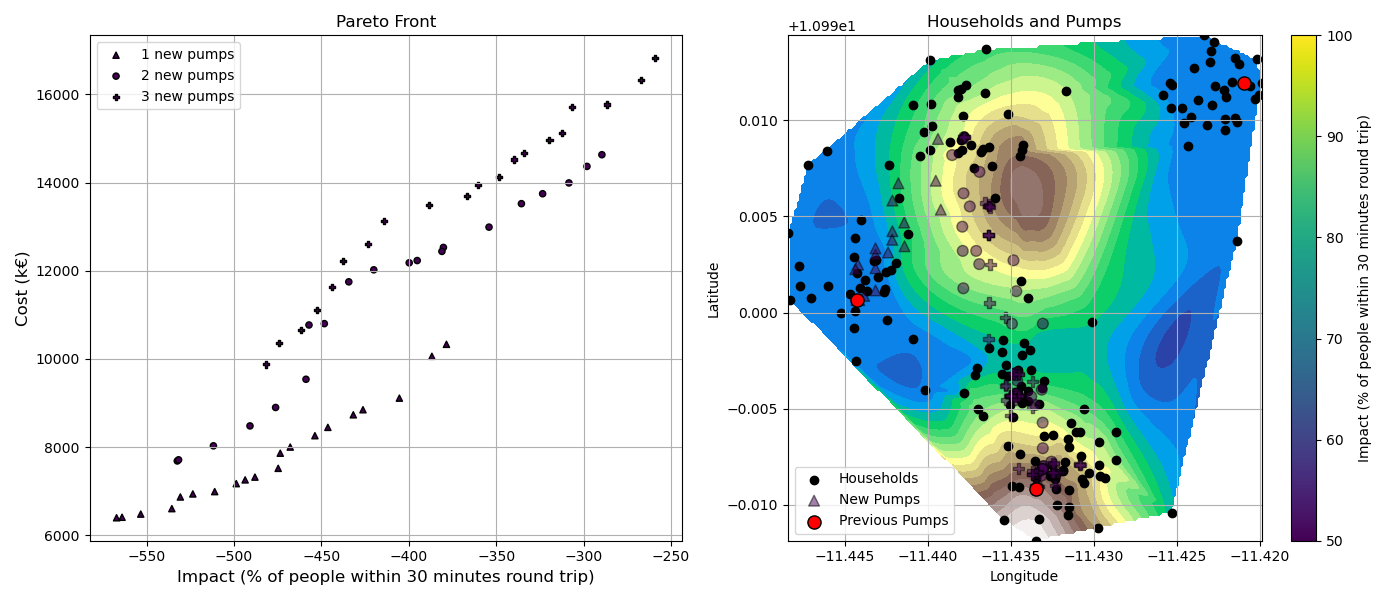

In [29]:
class InteractiveParetoPlot:
    def __init__(self, concatenated_result_vals, all_positions, all_result_vals, all_indices, 
                 households, pos_pumps, grid_x, grid_y, grid_z, initial_impact,pipe_data):
        # Store data
        self.concatenated_result_vals = concatenated_result_vals
        self.all_positions = all_positions
        self.all_result_vals = all_result_vals
        self.all_indices = all_indices
        self.households = households
        self.pos_pumps = pos_pumps
        self.grid_x = grid_x
        self.grid_y = grid_y
        self.grid_z = grid_z
        self.initial_impact = initial_impact
        self.pipe_data = pipe_data
        
        # Create figure and axes
        self.fig, (self.ax1, self.ax2) = plt.subplots(1, 2, figsize=(14, 6))
        
        # Store references to plot elements for highlighting
        self.pareto_scatter = None
        self.pump_scatters = []
        self.pump_lines = []
        self.highlighted_pumps = []
        self.highlighted_lines = []
        self.pipe_dataset = []
        self.data_boxes = []
        
        # Current hover index
        self.current_hover_idx = None
        
        self.setup_plots()
        self.connect_events()
    
    def setup_plots(self):
        """Set up both plots"""
        # === PARETO PLOT (ax1) ===
        n_tested = [1,2,3]
        n_shape = {1: '^', 2: 'o', 3: 'P'}
        
        # Store all scatter plots for hover detection
        self.pareto_scatters = []
        
        for n, k in enumerate(n_tested):
            scatter = self.ax1.scatter(
                -1*self.all_result_vals[n][:, 0], 
                self.all_result_vals[n][:, 1],
                c=-1*self.all_result_vals[n][:, 0],
                cmap='viridis',
                vmin=50,
                vmax=100,
                edgecolor='k',
                s=20,
                label=f'{k} new pumps',
                marker=n_shape[k],
            )
            self.pareto_scatters.append(scatter)
        
            
        
        self.ax1.set_xlabel('Impact (% of people within 30 minutes round trip)', fontsize=12)
        self.ax1.set_ylabel('Cost (k€)', fontsize=12)
        self.ax1.set_title('Pareto Front', fontsize=12)
        self.ax1.legend()
        self.ax1.grid(True)
        
        # === GEOGRAPHICAL PLOT (ax2) ===
        contour = self.ax2.contourf(self.grid_x, self.grid_y, self.grid_z, levels=20, cmap='terrain')
        
        # Plot households (black dots)
        self.ax2.scatter(self.households['Lon'], self.households['Lat'], color='black', label='Households')
        
        # Plot new pumps and store references
        n_tested = [1,2,3]
        n_shape = {1: '^', 2: 'o', 3: 'P'}
        
        pump_idx = 0  # Index to track pumps across all configurations
        
        for n, k in enumerate(n_tested):
            for i in range(k):
                pos_pumps_new_plot = self.all_positions[n][:,2*i:2*(i+1)]
                sc = self.ax2.scatter(
                    pos_pumps_new_plot[:, 0], pos_pumps_new_plot[:, 1],
                    c=-1*self.all_result_vals[n][:, 0],
                    cmap='viridis', 
                    edgecolor='k',
                    vmin=50,
                    vmax=100,
                    s=60,
                    label='New Pumps' if pump_idx == 0 else "",
                    marker=n_shape[k],
                    alpha=0.5
                )
                self.pump_scatters.append(sc)
                
                # Store lines for each solution in this pump configuration
                lines_for_config = []
                for j in range(len(pos_pumps_new_plot)):  # For each solution
                    solution_lines = []
                    if j < len(self.all_indices[n]) and i < self.all_indices[n].shape[1]:
                        if self.all_indices[n][j,i] < len(self.pos_pumps):
                            x = int(self.all_indices[n][j,i])
                            parent_coord = self.pos_pumps[x]
                        else:
                            x = int(self.all_indices[n][j,i] - len(self.pos_pumps))
                            if x < len(pos_pumps_new_plot):
                                parent_coord = self.all_positions[n][j,2*x:2*(x+1)]
                            else:
                                continue
                        
                        points_to_plot = np.array([pos_pumps_new_plot[j], parent_coord])
                        line, = self.ax2.plot(
                            points_to_plot[:, 0], points_to_plot[:, 1],
                            c='black',
                            alpha=0,
                            linewidth=1
                        )
                        solution_lines.append(line)
                    lines_for_config.append(solution_lines)
                
                self.pump_lines.append(lines_for_config)
                pump_idx += 1
                self.pipe_dataset.append(self.pipe_data[n][j])
        
        # Plot previous pumps (red)
        self.ax2.scatter(self.pos_pumps[:, 0], self.pos_pumps[:, 1], 
                        color='red', label='Previous Pumps', edgecolors='k', s=90)
        
        # Add colorbar
        if len(self.pump_scatters) > 0:
            cbar = self.fig.colorbar(self.pareto_scatters[-1], ax=self.ax2)
            cbar.set_label('Impact (% of people within 30 minutes round trip)')
        
        # Labels and title
        self.ax2.set_xlabel('Longitude')
        self.ax2.set_ylabel('Latitude')
        self.ax2.set_title('Households and Pumps')
        self.ax2.legend()
        self.ax2.grid(True)
        
        plt.tight_layout()
    
    def connect_events(self):
        """Connect mouse events"""
        self.fig.canvas.mpl_connect('motion_notify_event', self.on_hover)
    
    def on_hover(self, event):
        """Handle hover events over the Pareto plot"""
        if event.inaxes == self.ax1:
            # Check each scatter plot for hover
            hover_idx = None
            cumulative_solutions = 0
            
            for n, scatter in enumerate(self.pareto_scatters):
                cont, ind = scatter.contains(event)
                if cont:
                    # Get the index within this scatter plot
                    local_idx = ind["ind"][0]
                    # Convert to global index
                    hover_idx = cumulative_solutions + local_idx
                    break
                cumulative_solutions += len(self.all_result_vals[n])
            
            if hover_idx is not None:
                if hover_idx != self.current_hover_idx:
                    self.highlight_solution(hover_idx)
                    self.current_hover_idx = hover_idx
            else:
                # Clear highlighting if not hovering over any point
                if self.current_hover_idx is not None:
                    self.clear_highlighting()
                    self.current_hover_idx = None
    
    def highlight_solution(self, solution_idx):
        """Highlight the corresponding solution in the geographical plot"""
        self.clear_highlighting()
        
        # Find which configuration this solution belongs to
        cumulative_solutions = 0
        config_idx = None
        solution_in_config = None
        
        for n, k in enumerate([1, 2, 3]):
            num_solutions = len(self.all_result_vals[n])
            if cumulative_solutions <= solution_idx < cumulative_solutions + num_solutions:
                config_idx = n
                solution_in_config = solution_idx - cumulative_solutions
                break
            cumulative_solutions += num_solutions
        
        if config_idx is not None and solution_in_config is not None:
            # Highlight pumps for this specific solution
            pump_config_idx = 0
            for n in range(config_idx + 1):
                k = [1, 2, 3][n]
                if n == config_idx:
                    # This is our target configuration
                    for i in range(k):
                        if pump_config_idx < len(self.pump_scatters):
                            # Get the specific solution's pump positions
                            pos_pumps_new_plot = self.all_positions[n][:,2*i:2*(i+1)]
                            highlighted_scatter = self.ax2.scatter(
                                pos_pumps_new_plot[solution_in_config:solution_in_config+1, 0],
                                pos_pumps_new_plot[solution_in_config:solution_in_config+1, 1],
                                c='yellow',
                                s=150,
                                marker='*',
                                edgecolor='red',
                                linewidth=2,
                                zorder=10
                            )
                            self.highlighted_pumps.append(highlighted_scatter)
                            
                            # Highlight only the lines for this specific solution
                            if pump_config_idx < len(self.pump_lines):
                                if solution_in_config < len(self.pump_lines[pump_config_idx]):
                                    solution_lines = self.pump_lines[pump_config_idx][solution_in_config]
                                    for line in solution_lines:
                                        line.set_color('red')
                                        line.set_linewidth(3)
                                        line.set_alpha(1.0)
                                        self.highlighted_lines.append(line)
                                        
                            # these are matplotlib.patch.Patch properties
                            props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

                            
                            # # place a text box in upper left in axes coords
                            # text = self.pipe_dataset[pump_config_idx][solution_in_config]
                            # box = self.ax2.text(0.05, 0.95, text, 
                            #                     transform=self.ax2.transAxes, fontsize=8,
                            #                     verticalalignment='top', bbox=props)
                            
                            # self.data_boxes.append(box)
                        
                        pump_config_idx += 1
                else:
                    pump_config_idx += k
            
            # Refresh the plot
            self.fig.canvas.draw_idle()
    
    def clear_highlighting(self):
        """Clear all highlighting"""
        # Remove highlighted pumps
        for scatter in self.highlighted_pumps:
            scatter.remove()
        self.highlighted_pumps.clear()
        
        # Reset line properties
        for line in self.highlighted_lines:
            line.set_color('black')
            line.set_linewidth(1)
            line.set_alpha(0)
        self.highlighted_lines.clear()
        
        # for box in self.data_boxes:
        #     box.remove()
        # self.data_boxes.clear()
        
        # Refresh the plot
        self.fig.canvas.draw_idle()
    
    def show(self):
        """Display the interactive plot"""
        plt.show()

# Usage:
# Create the interactive plot
interactive_plot = InteractiveParetoPlot(
    concatenated_result_vals, all_positions, all_result_vals, all_indices,
    households, pos_pumps, grid_x, grid_y, grid_z, impact2(pos_pumps,pos_households,nb_capita),
    pipe_data,
)

# Show the plot
interactive_plot.show()

## NSGA Optimisation

In [30]:
def impact(pump_positions, household_positions, household_capita, x = None):
    min_pump_distance, min_pump_dist_indices = pump_distance(pump_positions, household_positions, x)

    impact = np.sum(household_capita * (min_pump_distance))
    return impact

initial_impact = impact(pos_pumps,pos_households,nb_capita)


bounds = np.array([
        [data['Lon'].min(), data['Lat'].min()],  # Min bounds
        [data['Lon'].max(), data['Lat'].max()],  # Max bounds
    ])
    

class MyProblem(ElementwiseProblem):
    def __init__(self, pump_specified=None):
        super().__init__(n_var=2, n_obj=2, n_constr=1, xl=bounds[0], xu=bounds[1])  # 2D search space
        self.pump_indices = []  # Store pump indices
        self.pump_specified = pump_specified  # Specify a pump index to be fixed

    def _evaluate(self, x, out, *args, **kwargs):

        # Compute weighted sum of distances to points in pos_households
        f1 = impact(pos_pumps,pos_households,nb_capita,x)-initial_impact  # Negative impact calculation with new x location
        
        # Compute minimum distance to any point in pos_pumps
        f2_distances = np.zeros(len(pos_pumps))
        for index,pump in enumerate(pos_pumps):
            f2_distances[index] = geo.great_circle(pump, x).meters
        
        
        if np.isnan(alt1:= interp(pump)) or np.isnan(alt2:= interp(x)):
            f2 = np.inf
        else:
            # If there is a specified pump, use distance to this pump
            if self.pump_specified is not None:
                cost_pipe_and_pumps, diameter_pipe,nb_pumps = pipe_and_pump_cost(alt1=alt1,alt2=alt2,
                                                                                length_pipe=f2_distances[self.pump_specified],
                                                                                flow_rate=1e-3,pump_data=pump_data,
                                                                                pipe_costs=pipe_costs)
                f2 = cost_conversion+cost_standpipe+cost_pipe_and_pumps[0]
            else:
                
                cost_pipe_and_pumps, diameter_pipe,nb_pumps = pipe_and_pump_cost(alt1=alt1,alt2=alt2,
                                                                                length_pipe=np.min(f2_distances),
                                                                                flow_rate=1e-3,pump_data=pump_data,
                                                                                pipe_costs=pipe_costs)
                f2 = cost_conversion+cost_standpipe+cost_pipe_and_pumps[0]
            


        # Define constraint: f1 >= c
        c = initial_impact
        g1 = f1-c

        out["F"] = [f1, f2]  # Objective functions
        out["G"] = [g1]  # Constraints (must be <= 0)

    def get_final_pump_indices(self, res):
        """Retrieve pump indices for the final generation."""
        self.pump_indices = []
        if self.pump_specified is not None:
            # If a pump is specified, use its index directly
            self.pump_indices = [self.pump_specified] * len(res.X)
        else:
            # If no pump is specified, find the closest pump for each solution
            for x in res.X:  # Iterate over the final generation's solutions
                f2_distances = np.zeros(len(pos_pumps))
                for index, pump in enumerate(pos_pumps):
                    f2_distances[index] = geo.great_circle(pump, x).meters
                pump_index = np.argmin(f2_distances)
                self.pump_indices.append(pump_index)


def optimise_nsgaII(pump_specified = None):
    # Define the NSGA-II optimization algorithm
    algorithm = NSGA2(
        pop_size=100,
        sampling=FloatRandomSampling(),
        crossover=SBX(prob=0.9, eta=15),
        mutation=PM(prob=0.1, eta=20),
        eliminate_duplicates=True
    )

    # Solve the problem
    problem = MyProblem(pump_specified)
    res = minimize(problem,
                algorithm,
                ('n_gen', 10),
                seed=1,
                verbose=True)
    
    problem.get_final_pump_indices(res)
    
    sol_pumps = np.array(problem.pump_indices)

    return res.X, res.F, sol_pumps

In [31]:
pump_specified = None  # Specify int pump index if constraint is needed
sol_pos,sol_val,sol_pumps = optimise_nsgaII(pump_specified)
pos_pumps_new = sol_pos

ValueError: `x` must be a 2-dimensional array.

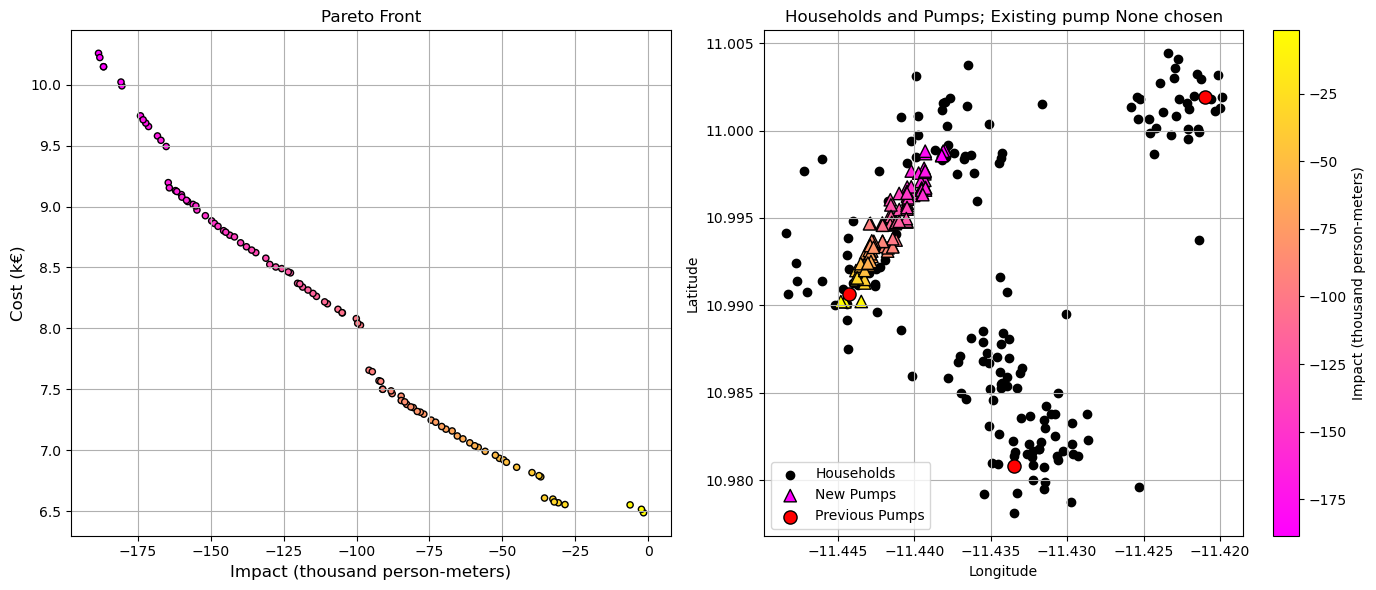

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# === PARETO PLOT (ax1) ===
ax1.scatter(sol_val[:,0]/1000,sol_val[:,1]/1000,c = sol_val[:,0], marker='o', s=20, cmap='spring', edgecolor='k')
ax1.set_xlabel('Impact (thousand person-meters)', fontsize=12)
ax1.set_ylabel('Cost (k€)', fontsize=12)
ax1.set_title('Pareto Front', fontsize=12)
ax1.grid(True)

# === GEOGRAPHICAL PLOT (ax2) ===

# Plot households (black dots)
ax2.scatter(households['Lon'], households['Lat'], color='black', label='Households')

# Plot new pumps, colored by first objective value
sc = ax2.scatter(
    pos_pumps_new[:, 0], pos_pumps_new[:, 1],
    c=sol_val[:, 0]/1000,
    cmap='spring', 
    edgecolor='k',
    s=80,
    label='New Pumps',
    marker='^'
)

# Plot previous pumps (red)
ax2.scatter(pos_pumps[:, 0], pos_pumps[:, 1], color='red', label='Previous Pumps', edgecolors='k', s=90)

# Add colorbar
cbar = fig.colorbar(sc, ax=ax2)
cbar.set_label('Impact (thousand person-meters)')

# Labels and title
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_title(f'Households and Pumps; Existing pump {pump_specified} chosen')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Find consumption at each standpipe for each possible solution

min_distance_pump, min_distance_index_pump = pump_distance(pos_pumps,pos_households,x=sol_pos)

pos_pumps_with_new = np.array([np.concatenate((pos_pumps,[pump]), axis=0) for j, pump in enumerate(sol_pos)])

pump_index_min = np.zeros((len(pos_pumps_with_new),len(pos_households)))
for i,household in enumerate(pos_households):
    for x in range(len(pos_pumps_with_new)):
        pump_distances = np.zeros(len(pos_pumps_with_new[x]))
        for k, pump in enumerate(pos_pumps_with_new[x]):
            pump_distances[k] = geo.great_circle(household, pump).meters
        pump_index_min[x,i] = np.argmin(pump_distances)


# Initialize consumption_pump to store the total consumption for each pump
consumption_pump = np.zeros((len(pos_pumps_with_new), len(pos_pumps) + 1))  # +1 for the new pump in each solution

# Update consumption_pump based on the closest pump
for x in range(len(pos_pumps_with_new)):  # Iterate over solutions
    for i, household in households.iterrows():  # Iterate over households
        closest_pump_index = int(pump_index_min[x, i])  # Closest pump index
        consumption_pump[x, closest_pump_index] += household['Nb capita'] * consumption_person

# for x in range(len(pos_pumps_with_new)):
#      for n_pumps in range(len(pos_pumps)):
#         consumption_pump[x,sol_pumps[x]] += consumption_pump[x,len(pos_pumps)]  # Add consumption from the new pump to the closest existing pump
#      consumption_pump[x, ]
# consumption_pump[:, ]        
#         if closest_pump_index == 3:
#             consumption_pump[x,sol_pumps[x]] += household['Nb capita'] * consumption_person  # Add consumption from the new pump to the closest existing pump

for x in range(len(pos_pumps_with_new)):  # Iterate over solutions
    consumption_pump[x, sol_pumps[x]] += consumption_pump[x, -1]  # Add consumption from the new pump to the closest existing pump
    

In [ ]:
# Debugging checks
# print(sol_pumps)
# print(consumption_pump[0,sol_pumps[0]]+consumption_pump[0,-1],baseline_consumption[0],consumption_pump[0,0])
# for i, household in households.iterrows():
#     if -11.435<=household['Lon']<=-11.43 and 10.99<=household['Lat']<=10.995:
#         print(household)

# print(pump_index_min[:, 145])


In [ ]:
print(baseline_consumption)

[6230. 5446. 2758.]


C:\Users\angus\AppData\Local\Temp\ipykernel_18208\2039077861.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 1])


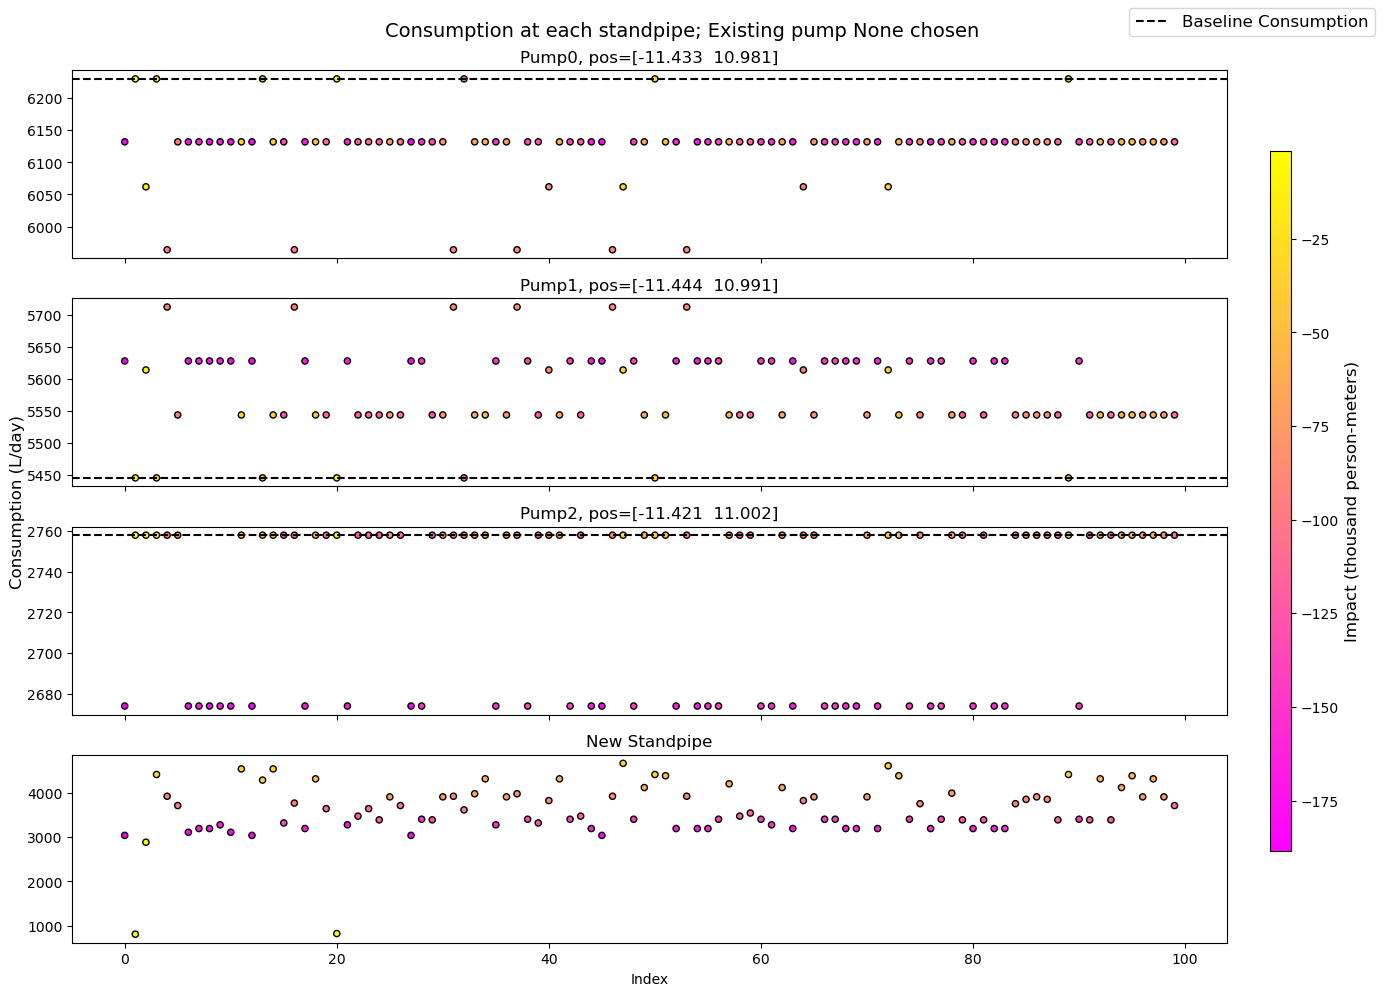

In [ ]:
indices = np.arange(len(pos_pumps_with_new))
# Plotting the consumption at each standpipe using matplotlib
fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

titles = [
    f'Pump0, pos={np.round(pos_pumps[0], 3)}',
    f'Pump1, pos={np.round(pos_pumps[1], 3)}',
    f'Pump2, pos={np.round(pos_pumps[2], 3)}',
    'New Standpipe'
]

# Use a consistent colormap
cmap = 'spring' 

for i in range(4):
    if i != 3:
        axs[i].axhline(y=baseline_consumption[i], color='black', linestyle='--', label='Baseline Consumption')
    sc = axs[i].scatter(
        indices,
        consumption_pump[:, i],
        c=sol_val[:, 0]/1000,
        cmap=cmap,
        s=20,
        edgecolor='k'
    )
    
    axs[i].set_title(titles[i])

axs[-1].set_xlabel("Index")
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(sc, cax=cbar_ax).set_label(label='Impact (thousand person-meters)', fontsize=12)
fig.suptitle(f"Consumption at each standpipe; Existing pump {pump_specified} chosen", fontsize=14)
fig.supylabel("Consumption (L/day)", fontsize=12)
legend_handles = plt.Line2D([0], [0],color='black',label='Baseline Consumption', linestyle='--')
fig.legend(handles=[legend_handles], loc='upper right', fontsize=12)
fig.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()
